In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import numpy as np
import scanpy as sc
import pickle
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from cellina import CellinaModel
from utils import set_seed, plot_results, evaluate_models

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get dataset

In [4]:
set_seed(0)

In [5]:
adata = sc.read("/data/a330d/projects/dsa/data/melanoma_cosmx_processed.h5ad")

In [6]:
split = "random"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    # Conditions
    is_fibro  = adata.obs["cell_type"].isin(["Fibroblast"])
    is_stress = adata.obs["region"] == "stressed"

    # Combine for test set
    test_mask = (is_stress) & (is_fibro)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [7]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [8]:
from sklearn.model_selection import train_test_split

validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

In [9]:
adata.layers.counts = adata.X.copy()

In [10]:
CellinaModel.setup_anndata(adata,
                           batch_key="CPID_str",
                           labels_key='celltype', 
                           domains_key='BEST_RESPONSE_BY_SCAN', 
                           spatial_obsm_key="neighborhood_pseudobulks")

INFO     Generating sequential column names                                                                        


In [11]:
base_path = "/data2/a330d/data/cellina-reproducibility/ablations"

# 1. Classifier

## Train

In [12]:
batch_size = 4096
max_epochs = 100
seeds = range(5)
lambda_ys = [0, 1e-9, 1e-7, 1e-3, 1., 1e3]
n_mc_samples = 500

In [13]:
for lambda_ in tqdm(lambda_ys, desc="Training (lambda_y)"):
    for seed in seeds:
        set_seed(seed)
        model = CellinaModel(
            adata, n_latent=64, 
            classifier_lambda=lambda_, 
            discriminator_lambda=1e-7,
            condition_on_intrinsic=False
        )
        model.train(
            max_epochs=max_epochs,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=25,
            early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
            plan_kwargs={
                'lr': 1e-4,
                'normalize_losses': True,
            },
            datasplitter_kwargs={
                "external_indexing": [train_idx, val_idx, test_idx],
            },
            enable_checkpointing=True,
            batch_size=batch_size,
            devices=[1],
        )

        model.save(f"{base_path}/trained/lambda_y_{lambda_}_seed_{seed}", overwrite=True)

Training (lambda_y):   0%|          | 0/6 [00:00<?, ?it/s]

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many 

Epoch 89/100:  89%|████████▉ | 89/100 [01:58<00:14,  1.33s/it, v_num=1, train_loss=12.8] 
Monitored metric validation_loss did not improve in the last 25 records. Best score: 515.630. Signaling Trainer to stop.
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


...

Epoch 80/100:  80%|████████  | 80/100 [01:46<00:26,  1.33s/it, v_num=1, train_loss=419]
Monitored metric validation_loss did not improve in the last 25 records. Best score: 520.407. Signaling Trainer to stop.
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 77/100:  77%|███████▋  | 77/100 [01:41<00:30,  1.32s/it, v_num=1, train_loss=416]

Training (lambda_y): 100%|██████████| 6/6 [58:50<00:00, 588.44s/it]


Monitored metric validation_loss did not improve in the last 25 records. Best score: 521.041. Signaling Trainer to stop.


## Eval

In [14]:
target_col = 'celltype'
df_lambda_y = evaluate_models(
    adata,
    seeds,
    lambda_type="lambda_y",
    lambda_values=lambda_ys,
    target_col=target_col,
    root_dir=f"{base_path}/trained",
)

Evaluating (lambda_y):   0%|          | 0/6 [00:00<?, ?it/s]Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_y_0_seed_0/model.pt already       
         downloaded                                                                                                


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_y_0_seed_1/model.pt already       
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


...

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_y_1000.0_seed_3/model.pt already  
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_y_1000.0_seed_4/model.pt already  
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


Evaluating (lambda_y): 100%|██████████| 6/6 [12:35<00:00, 125.86s/it]


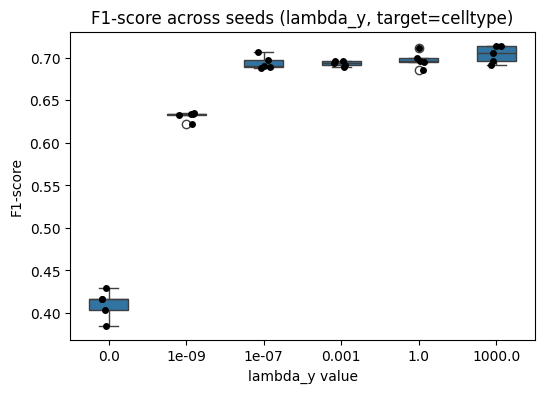

In [15]:
# melanoma
plot_results(df_lambda_y, lambda_type="lambda_y", target_col=target_col)

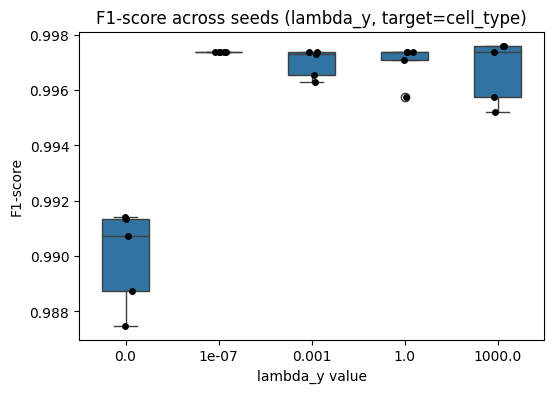

In [ ]:
# sim
plot_results(df_lambda_y, lambda_type="lambda_y", target_col=target_col)

In [16]:
target_col = 'BEST_RESPONSE_BY_SCAN'
df_lambda_y_spatial = evaluate_models(
    adata,
    seeds,
    lambda_type="lambda_y",
    lambda_values=lambda_ys,
    target_col=target_col,
    root_dir=f"{base_path}/trained",
)

Evaluating (lambda_y):   0%|          | 0/6 [00:00<?, ?it/s]Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_y_0_seed_0/model.pt already       
         downloaded                                                                                                


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_y_0_seed_1/model.pt already       
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


...

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_y_1000.0_seed_3/model.pt already  
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_y_1000.0_seed_4/model.pt already  
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


Evaluating (lambda_y): 100%|██████████| 6/6 [03:09<00:00, 31.55s/it]


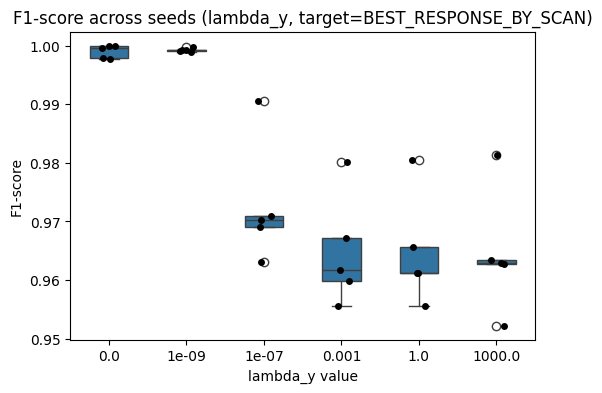

In [17]:
# melanoma
plot_results(df_lambda_y_spatial, lambda_type="lambda_y", target_col=target_col)

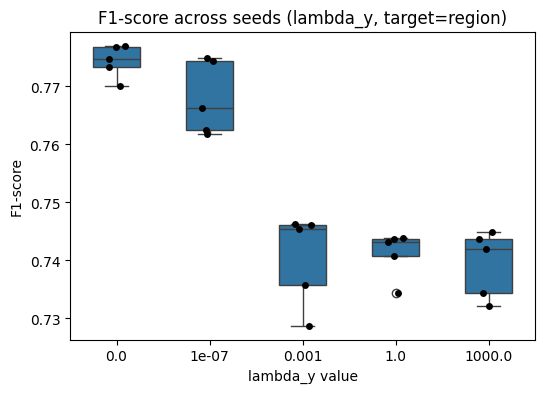

In [ ]:
# sim
plot_results(df_lambda_y_spatial, lambda_type="lambda_y", target_col=target_col)

# 2. Discriminator

## Train

In [18]:
lambda_ds = lambda_ys

In [19]:
for lambda_ in tqdm(lambda_ds, desc="Training (lambda_d)"):
    for seed in seeds:
        set_seed(seed)
        model = CellinaModel(
            adata, n_latent=64, 
            classifier_lambda=1e-7, 
            discriminator_lambda=lambda_,
            condition_on_intrinsic=False
        )
        model.train(
            max_epochs=max_epochs,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=25,
            early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
            plan_kwargs={
                'lr': 1e-4,
                'normalize_losses': True,
            },
            datasplitter_kwargs={
                "external_indexing": [train_idx, val_idx, test_idx],
            },
            enable_checkpointing=True,
            batch_size=batch_size,
            devices=[1],
        )

        model.save(f"{base_path}/trained/lambda_d_{lambda_}_seed_{seed}", overwrite=True)

Training (lambda_d):   0%|          | 0/6 [00:00<?, ?it/s]

INFO     cellina: The Cellina model has been initialized                                                           


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [01:40<00:00,  1.01it/s, v_num=1, train_loss_step=503, train_loss_epoch=494]

`Trainer.fit` stopped: `max_epochs=100` reached.


...

Epoch 93/100:  93%|█████████▎| 93/100 [01:38<00:07,  1.06s/it, v_num=1, train_loss=251]
Monitored metric validation_loss did not improve in the last 25 records. Best score: 518.097. Signaling Trainer to stop.
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 95/100:  95%|█████████▌| 95/100 [01:46<00:05,  1.12s/it, v_num=1, train_loss=245]

Training (lambda_d): 100%|██████████| 6/6 [47:29<00:00, 474.94s/it]


Monitored metric validation_loss did not improve in the last 25 records. Best score: 518.905. Signaling Trainer to stop.


## Eval

In [20]:
df_lambda_d = evaluate_models(
    adata,
    seeds,
    lambda_type="lambda_d",
    lambda_values=lambda_ds,
    target_col="BEST_RESPONSE_BY_SCAN",
    root_dir=f"{base_path}/trained",
)

Evaluating (lambda_d):   0%|          | 0/6 [00:00<?, ?it/s]Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_d_0_seed_0/model.pt already       
         downloaded                                                                                                


INFO     cellina: The Cellina model has been initialized                                                           


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_d_0_seed_1/model.pt already       
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized                                                           


...

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_d_1000.0_seed_3/model.pt already  
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_d_1000.0_seed_4/model.pt already  
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


Evaluating (lambda_d): 100%|██████████| 6/6 [03:47<00:00, 37.91s/it]


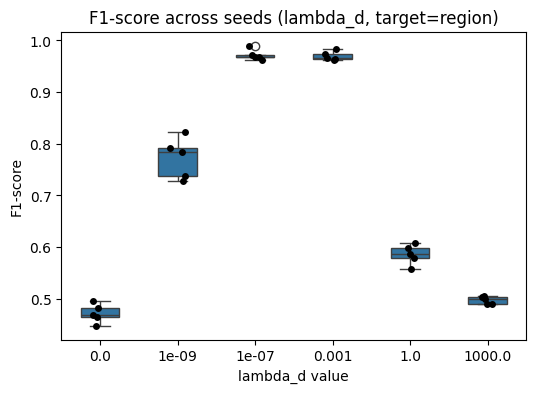

In [21]:
# melanoma
plot_results(df_lambda_d, lambda_type="lambda_d", target_col='region')

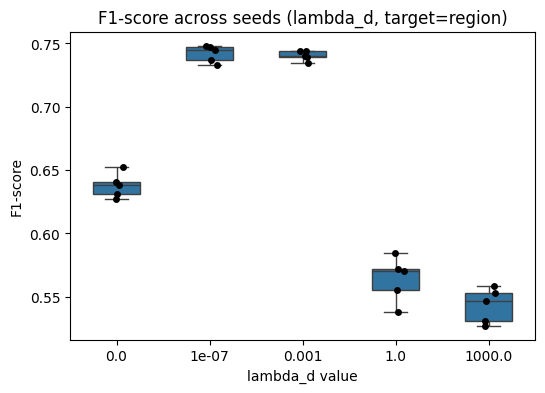

In [ ]:
# sim
plot_results(df_lambda_d, lambda_type="lambda_d", target_col='region')

# 3. Edge predictor

## Train

In [ ]:
alpha_edge = [0., 0.01, 5, 1000, 1000000]

In [ ]:
for alpha in tqdm(alpha_edge, desc="Training (alpha_edge)"):
    for seed in seeds:
        set_seed(seed)
        model = CellinaModel(
            adata_train, n_latent=64, 
            classifier_lambda=1e2, 
            discriminator_lambda=1e2,
            link_prediction_weight=alpha,
        )
        model.train(
            max_epochs=epochs,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=25,
            early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
            train_size=0.9,
            validation_size=0.1,
            plan_kwargs={
                "lr": 0.0001,
                "weight_decay": 0.0001,
            },
            enable_checkpointing=True,
            batch_size=2048,
            devices=[1],
        )

        model.save(f"{base_path}/trained/alpha_edge_{alpha}_seed_{seed}", overwrite=True)

## Eval

In [ ]:
df_alpha_edge = evaluate_models(
    adata,
    seeds,
    alpha_type="alpha_edge",
    alpha_values=alpha_edge,
    target_col="BEST_RESPONSE_BY_SCAN",
    latent_key='s',
    root_dir=f"{base_path}/trained",
)

In [ ]:
plot_results(df_alpha_edge, alpha_type="alpha_edge", target_col='BEST_RESPONSE_BY_SCAN')

# Evaluate Marginal LL via Importance Sampling to see holdout data fit

In [22]:
results = {"lambda_y": {}, "lambda_d": {}}
for lambda_type in results.keys():
    for lambda_ in lambda_ys:
        res_by_seed = []
        for seed in seeds:
            set_seed(seed)
            save_path = f"{base_path}/trained/{lambda_type}_{lambda_}_seed_{seed}"

            model = CellinaModel.load(save_path, adata)

            mll = model.get_marginal_ll(adata=adata[adata.obs['is_holdout']], 
                                        n_mc_samples=n_mc_samples,
                                        return_mean=True)
            res_by_seed.append(mll)
        results[lambda_type][lambda_] = res_by_seed

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_y_0_seed_0/model.pt already       
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 3 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_y_0_seed_1/model.pt already       
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 3 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


...

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 3 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_d_1000.0_seed_3/model.pt already  
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 3 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_d_1000.0_seed_4/model.pt already  
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 3 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


In [23]:
with open(f"../results/mll_gridsearch_melanoma_{split}.pkl", "wb") as f:
    pickle.dump(results, f)

## Plot

In [24]:
with open(f"../results/mll_gridsearch_melanoma_{split}.pkl", "rb") as f:
    results = pickle.load(f)

In [25]:
def plot_mll_boxplot(results, title="Marginal LL on holdout (Higher is better)"):
    lambdas = list(results.keys())
    data = [results[c] for c in lambdas]

    fig, ax = plt.subplots(figsize=(6, 4))

    bp = ax.boxplot(
        data,
        patch_artist=True,   # allows facecolor
        labels=lambdas,
        medianprops=dict(color='black', linewidth=2)
    )


    # Optional: jittered points overlaid on the boxes
    for i, cond in enumerate(lambdas):
        y = np.array(results[cond])
        x = np.random.normal(i+1, 0.04, size=len(y))   # jitter for visibility
        ax.scatter(x, y, color="black", s=30, zorder=3)

    ax.set_xlabel("$\lambda$ strength")
    ax.set_ylabel("Marginal LL")
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3395819/3261663957.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


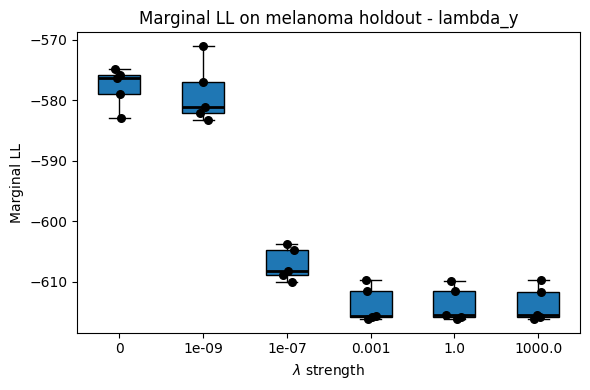

In [26]:
# melanoma
plot_mll_boxplot(results['lambda_y'], title="Marginal LL on melanoma holdout - lambda_y")

/tmp/ipykernel_1201087/3261663957.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


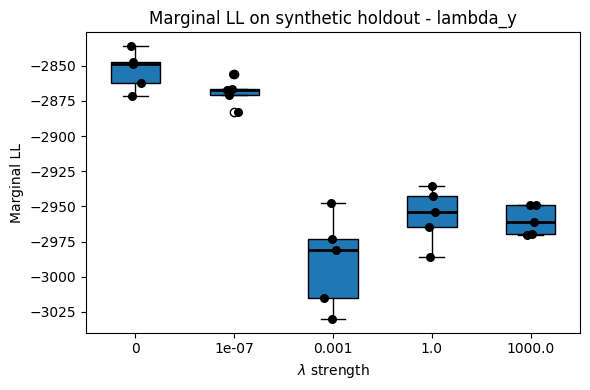

In [ ]:
# sim
plot_mll_boxplot(results['lambda_y'], title="Marginal LL on synthetic holdout - lambda_y")

/tmp/ipykernel_3395819/3261663957.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


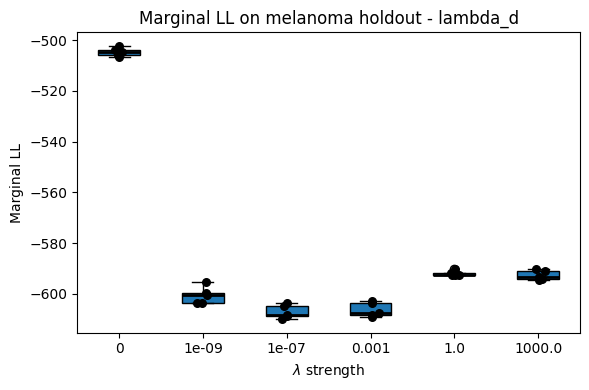

In [27]:
# melanoma
plot_mll_boxplot(results['lambda_d'], title="Marginal LL on melanoma holdout - lambda_d")

/tmp/ipykernel_1201087/3261663957.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


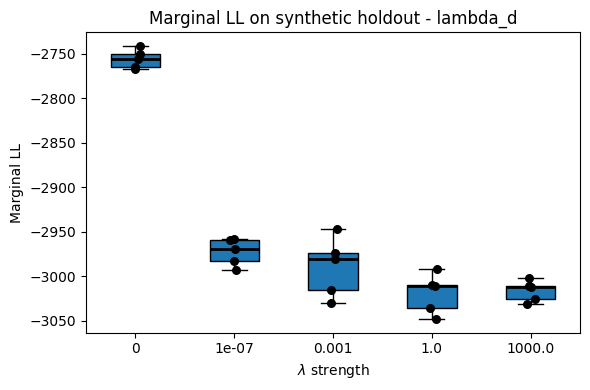

In [ ]:
# sim
plot_mll_boxplot(results['lambda_d'], title="Marginal LL on synthetic holdout - lambda_d")